In [3]:
import pandas as pd

df_monthly = pd.read_csv(r"C:\Users\tedvm\Centrale\PoleProjetS8\Data_PublicHealth_CentraleSupelec\data\google_trends\google_trends_health_FR_monthly_2015_2026.csv")

df_weekly = pd.read_csv(r"C:\Users\tedvm\Centrale\PoleProjetS8\Data_PublicHealth_CentraleSupelec\data\google_trends\google_trends_health_FR_weekly_2021_2026.csv")

display(df_monthly.head())
display(df_weekly.head())

,date,interest,keyword,query_combined
0,2015-01-01,1,Dry January,Dry January + janvier sans alcool + detox alco...
1,2015-02-01,0,Dry January,Dry January + janvier sans alcool + detox alco...
2,2015-03-01,0,Dry January,Dry January + janvier sans alcool + detox alco...
3,2015-04-01,0,Dry January,Dry January + janvier sans alcool + detox alco...
4,2015-05-01,1,Dry January,Dry January + janvier sans alcool + detox alco...


,date,interest,keyword,query_combined
0,2020-12-27,19,Dry January,Dry January + janvier sans alcool + detox alco...
1,2021-01-03,39,Dry January,Dry January + janvier sans alcool + detox alco...
2,2021-01-10,18,Dry January,Dry January + janvier sans alcool + detox alco...
3,2021-01-17,7,Dry January,Dry January + janvier sans alcool + detox alco...
4,2021-01-24,5,Dry January,Dry January + janvier sans alcool + detox alco...


In [5]:
#infos sur les dataframes
#monthly
df_monthly.shape
df_monthly.columns
df_monthly.info()

#weekly
df_weekly.shape
df_weekly.columns
df_weekly.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532 entries, 0 to 531
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            532 non-null    object
 1   interest        532 non-null    int64 
 2   keyword         532 non-null    object
 3   query_combined  532 non-null    object
dtypes: int64(1), object(3)
memory usage: 16.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3930 entries, 0 to 3929
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            3930 non-null   object
 1   interest        3930 non-null   int64 
 2   keyword         3930 non-null   object
 3   query_combined  3930 non-null   object
dtypes: int64(1), object(3)
memory usage: 122.9+ KB


In [6]:
#traitement de la colonne date pour en faire un index temporel
if "date" in df_monthly.columns:
    df_monthly["date"] = pd.to_datetime(df_monthly["date"])
    df_monthly = df_monthly.sort_values("date")
    df_monthly = df_monthly.set_index("date")
else:
    # Date is already the index, just ensure it's sorted
    df_monthly.index = pd.to_datetime(df_monthly.index)
    df_monthly = df_monthly.sort_index()


if "date" in df_weekly.columns:
    df_weekly["date"] = pd.to_datetime(df_weekly["date"])
    df_weekly = df_weekly.sort_values("date")
    df_weekly = df_weekly.set_index("date")
else:
    # Date is already the index, just ensure it's sorted
    df_weekly.index = pd.to_datetime(df_weekly.index)
    df_weekly = df_weekly.sort_index()

display(df_monthly.head())
display(df_weekly.head())



,interest,keyword,query_combined
date,,,
2015-01-01,1,Dry January,Dry January + janvier sans alcool + detox alco...
2015-01-01,35,Mars bleu,Mars bleu + cancer colorectal + dépistage colo...
2015-01-01,33,Movember,Movember + cancer prostate + dépistage prostat...
2015-01-01,9,Octobre rose,Octobre rose + cancer du sein + mammographie +...
2015-02-01,39,Mars bleu,Mars bleu + cancer colorectal + dépistage colo...


,interest,keyword,query_combined
date,,,
2020-12-27,19,Dry January,Dry January + janvier sans alcool + detox alco...
2020-12-27,39,Journée mondiale sans tabac,world no tobacco day + arrêter fumer + dangers...
2020-12-27,32,Mars bleu,Mars bleu + cancer colorectal + dépistage colo...
2020-12-27,14,Journée mondiale du handicap,journée handicap + inclusion handicap + access...
2020-12-27,12,Mois sans tabac,Mois sans tabac + arrêter fumer + sevrage nico...


In [11]:
#on change la forme du fichier pour faciliter les manipulations

df_monthly_wide = df_monthly.pivot(columns="keyword", values="interest")
df_monthly_wide = df_monthly_wide.sort_index()

df_weekly_wide = df_weekly.pivot(columns="keyword", values="interest")
df_weekly_wide = df_weekly_wide.sort_index()

display(df_monthly_wide.head())
display(df_weekly_wide.head())

keyword,Dry January,Mars bleu,Movember,Octobre rose
date,,,,
2015-01-01,1,35,33,9
2015-02-01,0,39,34,10
2015-03-01,0,43,30,10
2015-04-01,0,35,27,10
2015-05-01,1,41,28,9


keyword,Dry January,Journée mondiale de la santé mentale,Journée mondiale de la trisomie 21,Journée mondiale de lutte contre l'obésité,Journée mondiale de lutte contre le cancer,Journée mondiale du handicap,Journée mondiale sans tabac,Journée nationale des aidants,Juin vert,Mars bleu,Mois sans tabac,Movember,Octobre rose,Sidaction,World Health Day
date,,,,,,,,,,,,,,,
2020-12-27,19,49,28,44,14,14,39,19,20,32,12,19,6,17,8
2021-01-03,39,61,33,53,27,24,49,29,22,45,14,21,8,19,12
2021-01-10,18,58,37,59,23,22,44,34,21,48,14,22,8,19,11
2021-01-17,7,58,35,62,22,21,46,29,23,50,14,24,8,18,7
2021-01-24,5,57,32,53,34,21,40,28,16,53,12,21,7,44,9


In [ ]:
#on crée les fichiers csv pour les analyses futures
df_monthly_wide.to_csv(r"C:\Users\tedvm\Centrale\PoleProjetS8\Data_PublicHealth_CentraleSupelec\data\google_trends\google_trends_health_FR_monthly_2015_2026_wide.csv")
df_weekly_wide.to_csv(r"C:\Users\tedvm\Centrale\PoleProjetS8\Data_PublicHealth_CentraleSupelec\data\google_trends\google_trends_health_FR_weekly_2021_2026_wide.csv")

In [14]:
display(df_monthly_wide.describe())
display(df_weekly_wide.describe())


keyword,Dry January,Mars bleu,Movember,Octobre rose
count,133.000000,133.000000,133.000000,133.000000
mean,6.624060,47.406015,38.992481,18.195489
std,15.938614,12.663499,14.426667,14.451307
min,0.000000,22.000000,22.000000,7.000000
25%,1.000000,39.000000,30.000000,11.000000
50%,2.000000,43.000000,35.000000,14.000000
75%,3.000000,55.000000,42.000000,19.000000
max,100.000000,100.000000,100.000000,100.000000


keyword,Dry January,Journée mondiale de la santé mentale,Journée mondiale de la trisomie 21,Journée mondiale de lutte contre l'obésité,Journée mondiale de lutte contre le cancer,Journée mondiale du handicap,Journée mondiale sans tabac,Journée nationale des aidants,Juin vert,Mars bleu,Mois sans tabac,Movember,Octobre rose,Sidaction,World Health Day
count,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000
mean,4.152672,71.954198,31.293893,40.866412,39.568702,39.213740,43.717557,35.973282,34.213740,53.366412,18.629771,27.820611,13.244275,19.912214,14.003817
std,11.169522,10.684154,10.124582,7.883813,15.439942,15.580717,9.060271,10.903058,14.630052,11.025367,12.589159,11.712156,12.586005,11.670932,11.559441
min,0.000000,49.000000,20.000000,25.000000,11.000000,11.000000,27.000000,15.000000,13.000000,31.000000,9.000000,17.000000,6.000000,10.000000,4.000000
25%,0.000000,63.000000,27.000000,36.000000,29.000000,27.000000,38.000000,29.000000,24.000000,46.000000,13.000000,22.000000,8.000000,16.000000,9.000000
50%,1.000000,73.000000,29.000000,40.000000,36.500000,39.000000,43.000000,35.000000,31.000000,53.000000,15.000000,24.000000,10.000000,18.000000,11.000000
75%,2.000000,80.000000,32.000000,45.000000,46.750000,49.000000,47.000000,42.000000,40.750000,59.000000,17.000000,28.000000,12.000000,20.000000,14.000000
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


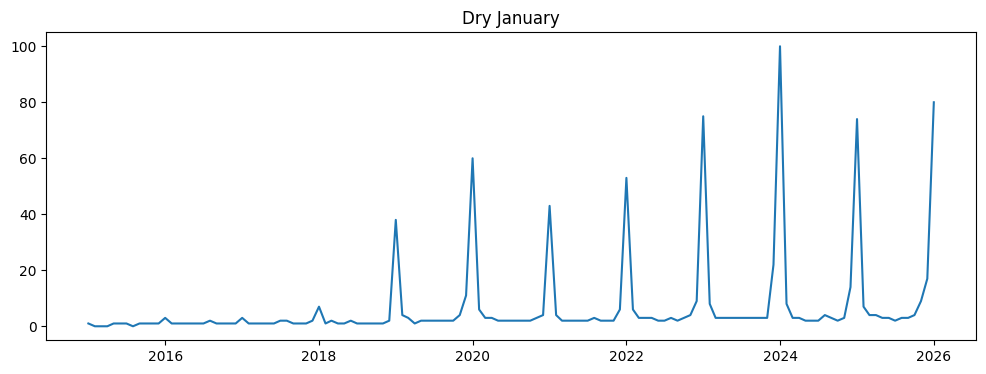

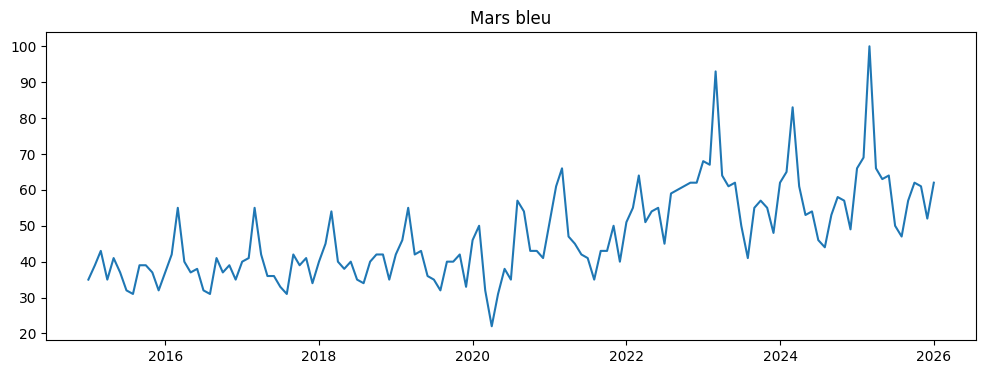

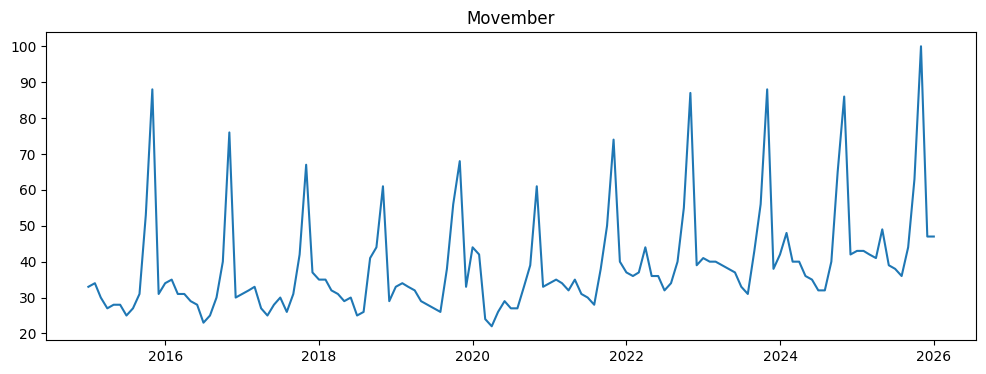

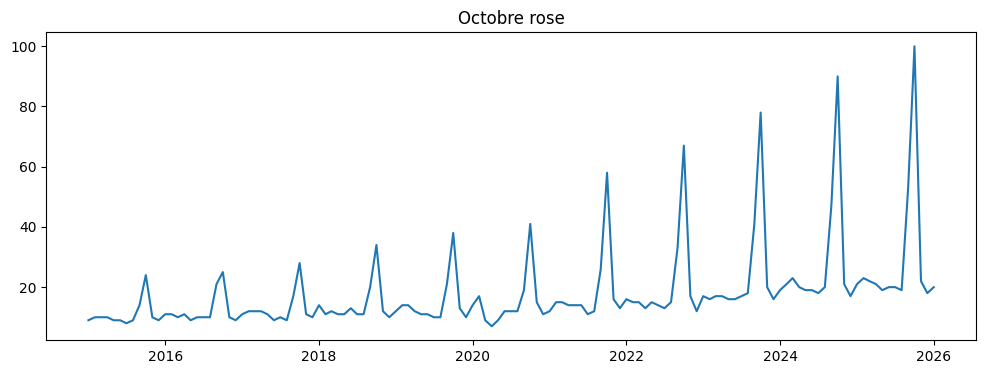

In [15]:
#première visualisation rapide mensuelle

import matplotlib.pyplot as plt

for col in df_monthly_wide.columns:
    plt.figure(figsize=(12,4))
    plt.plot(df_monthly_wide.index, df_monthly_wide[col])
    plt.title(col)
    plt.show()

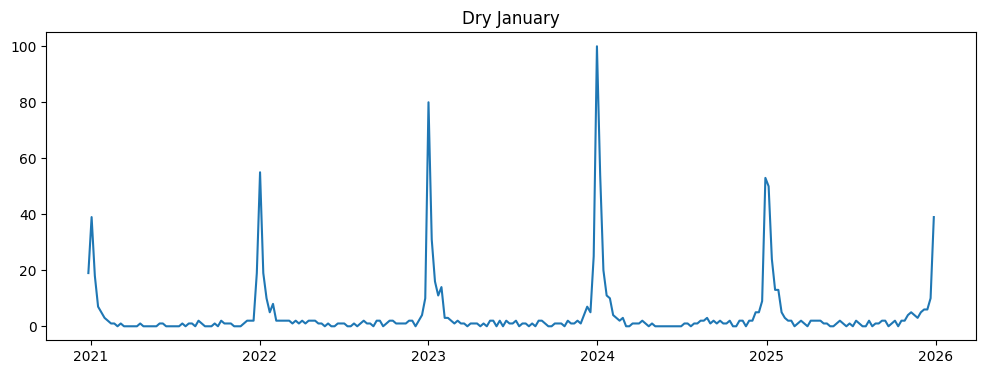

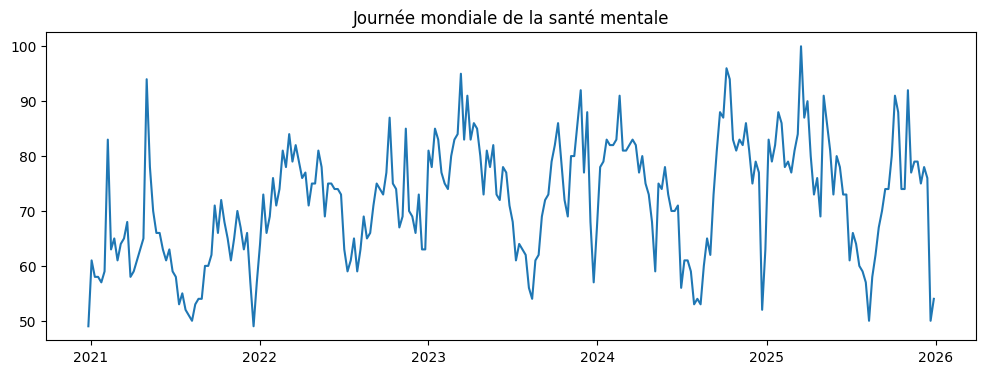

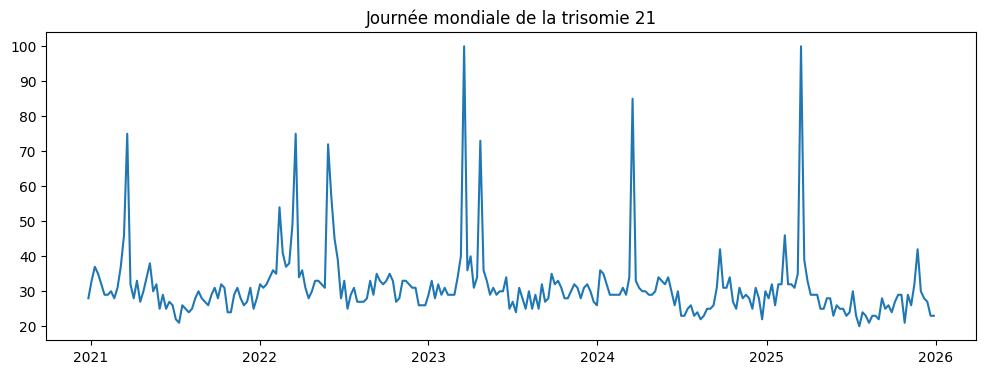

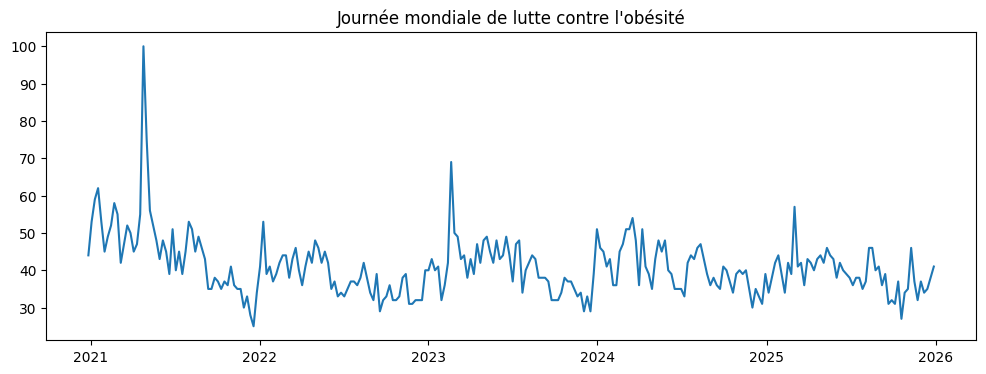

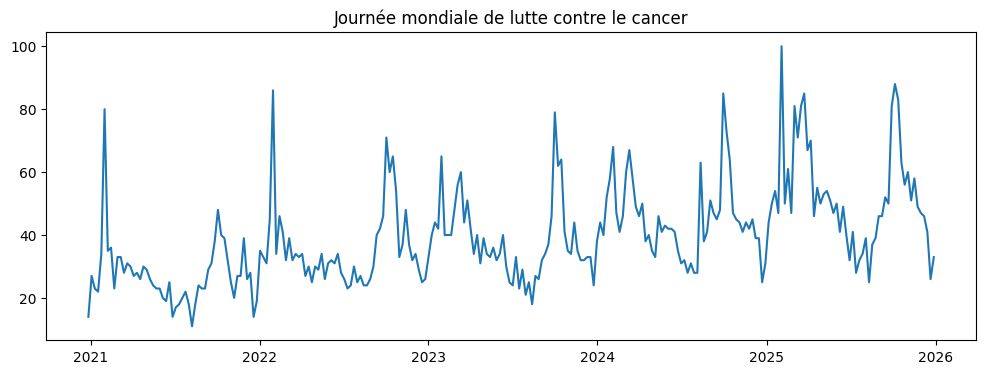

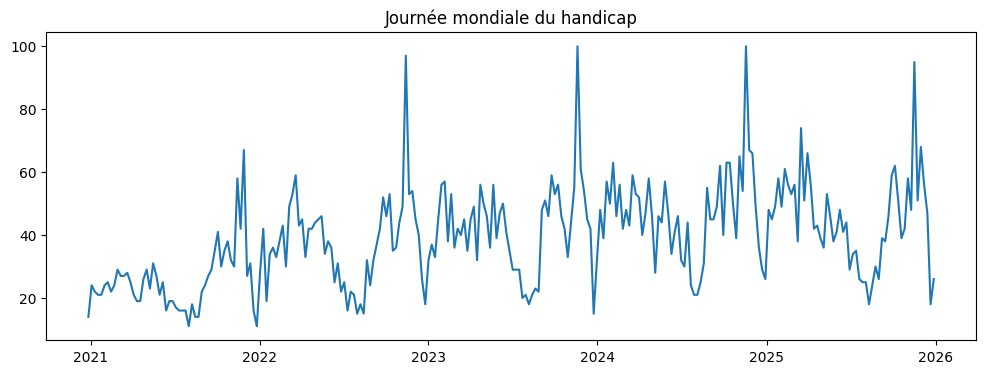

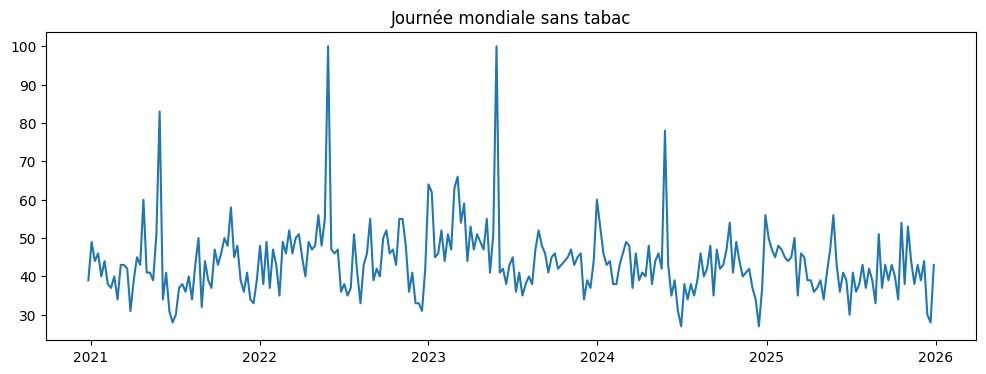

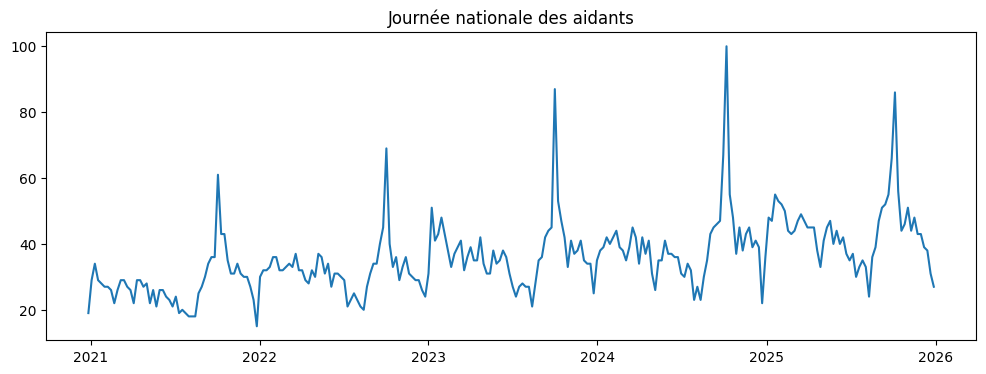

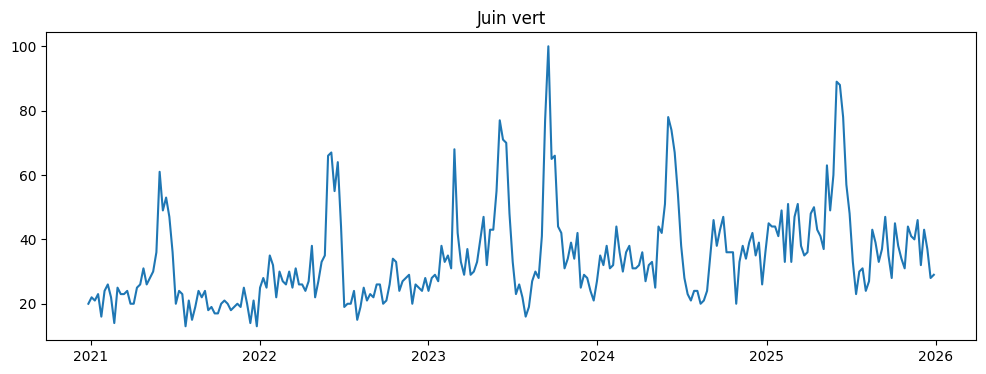

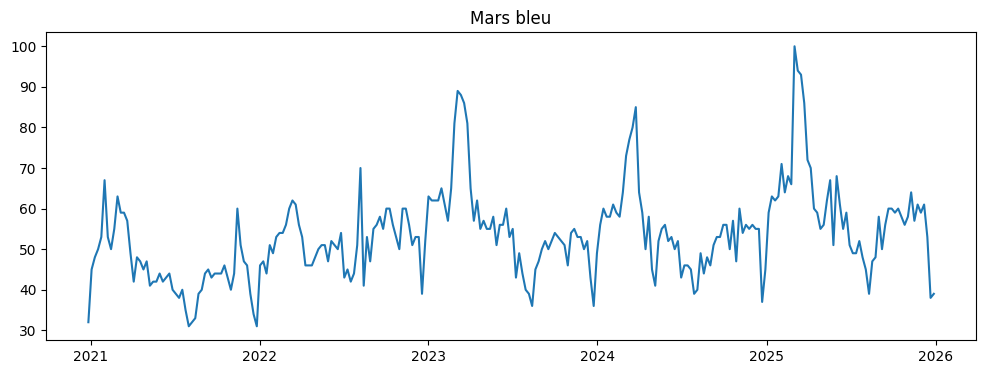

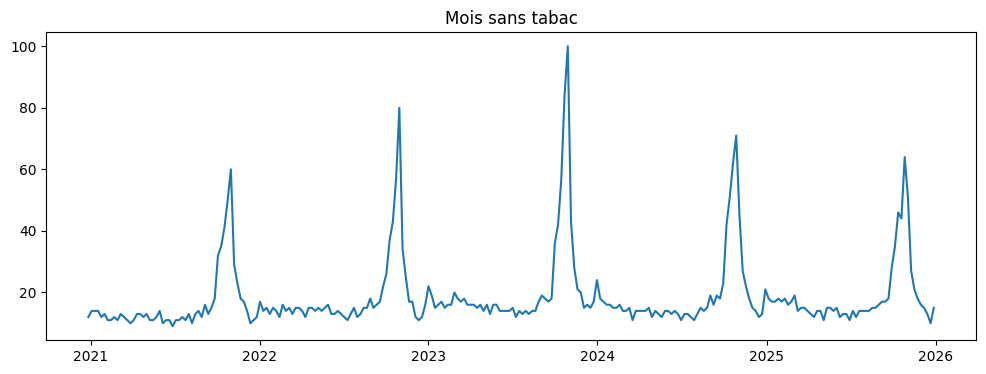

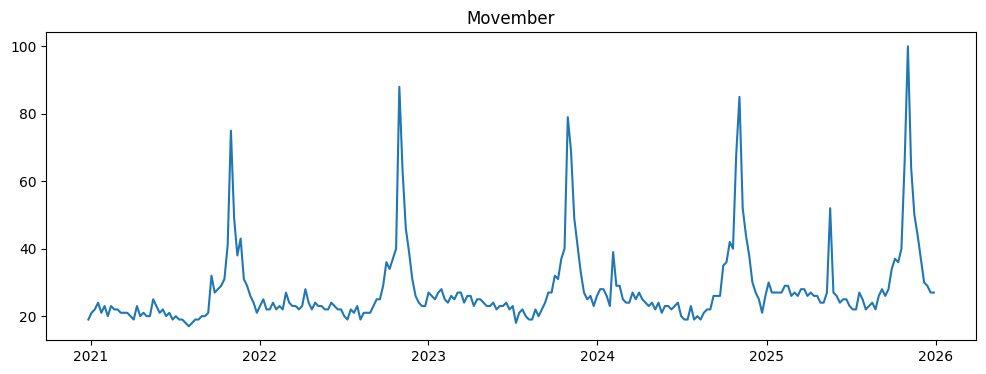

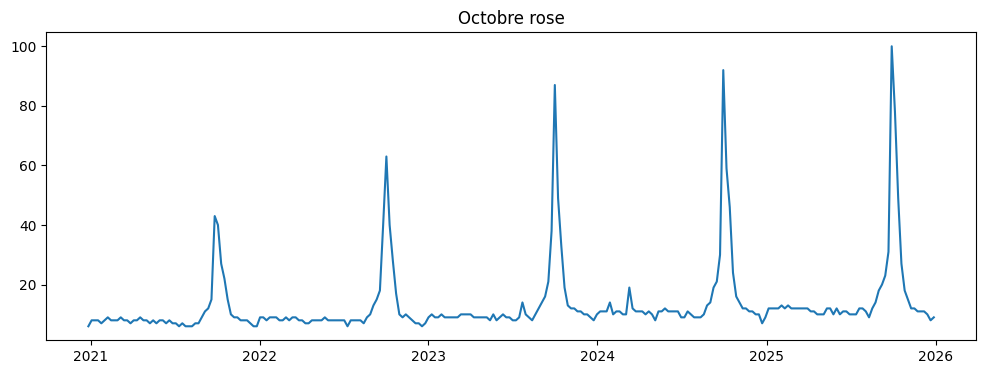

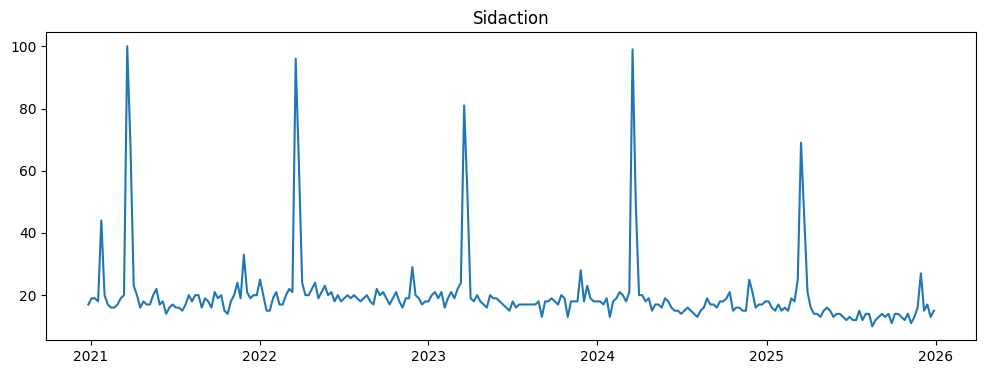

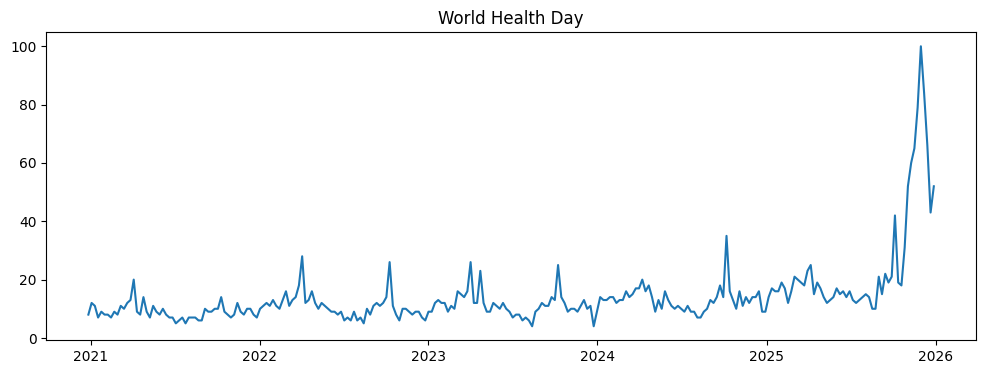

In [16]:
#première visualisation rapide hebdo
import matplotlib.pyplot as plt

for col in df_weekly_wide.columns:
    plt.figure(figsize=(12,4))
    plt.plot(df_weekly_wide.index, df_weekly_wide[col])
    plt.title(col)
    plt.show()

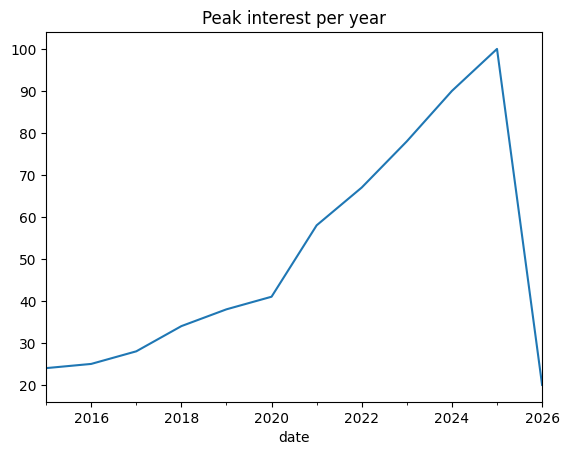

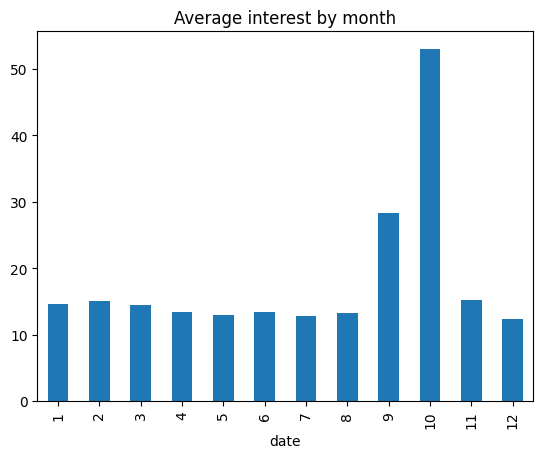

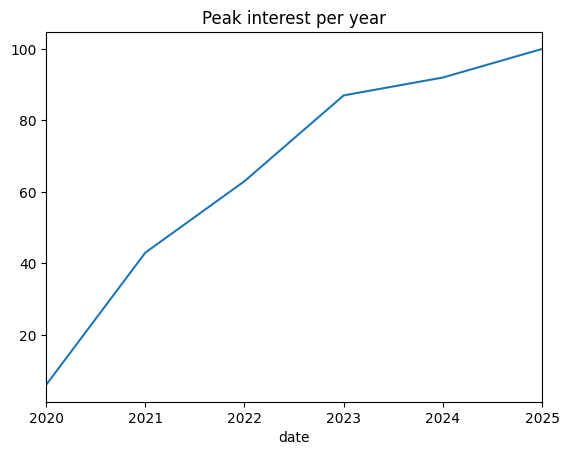

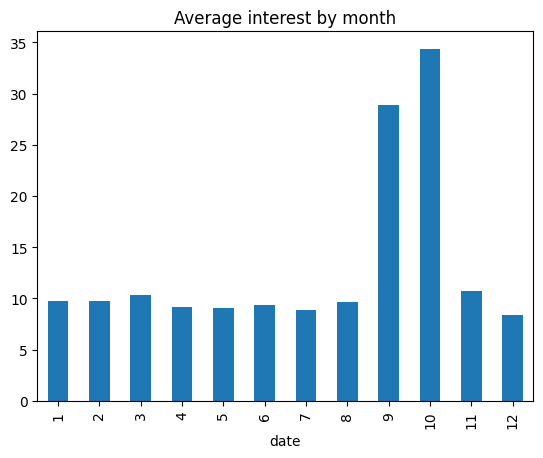

In [18]:
df_monthly_wide["Octobre rose"].resample("YE").max().plot()
plt.title("Peak interest per year")
plt.show()

df_monthly_wide.groupby(df_monthly_wide.index.month)["Octobre rose"].mean().plot(kind="bar")
plt.title("Average interest by month")
plt.show()

df_weekly_wide["Octobre rose"].resample("YE").max().plot()
plt.title("Peak interest per year")
plt.show()

df_weekly_wide.groupby(df_weekly_wide.index.month)["Octobre rose"].mean().plot(kind="bar")
plt.title("Average interest by month")
plt.show()

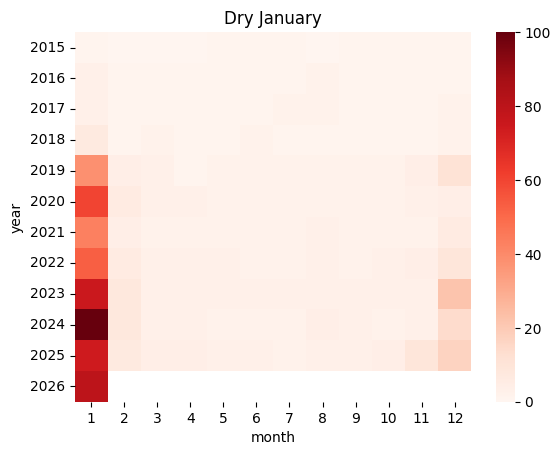

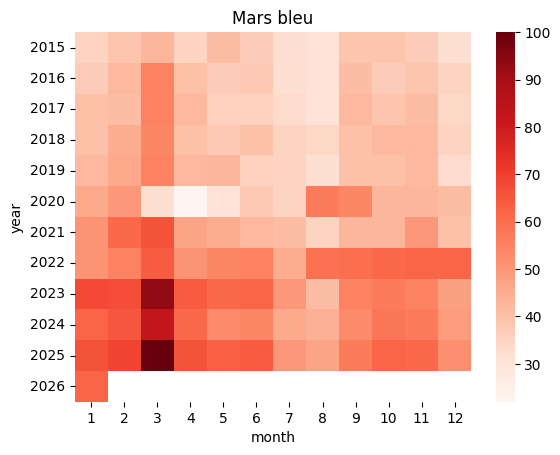

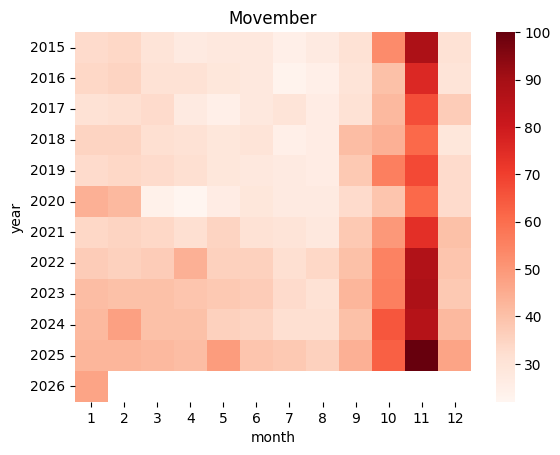

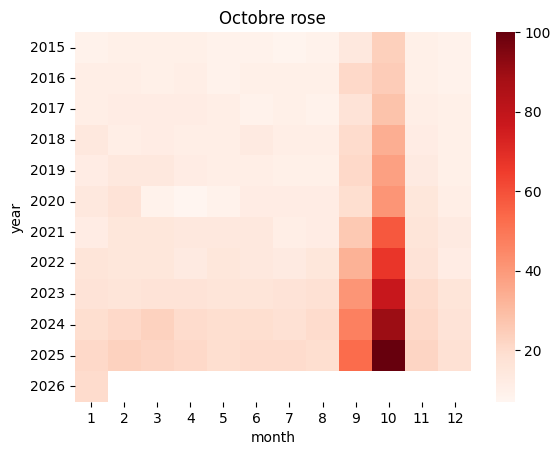

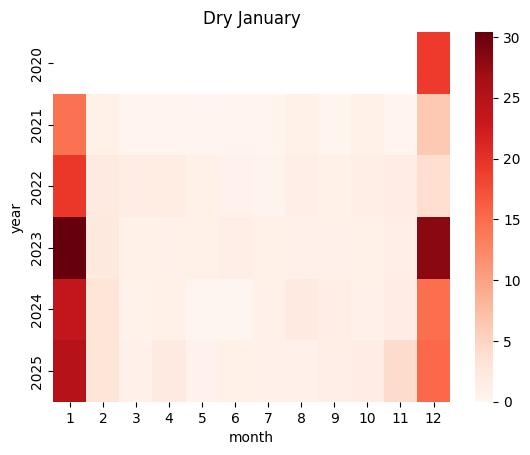

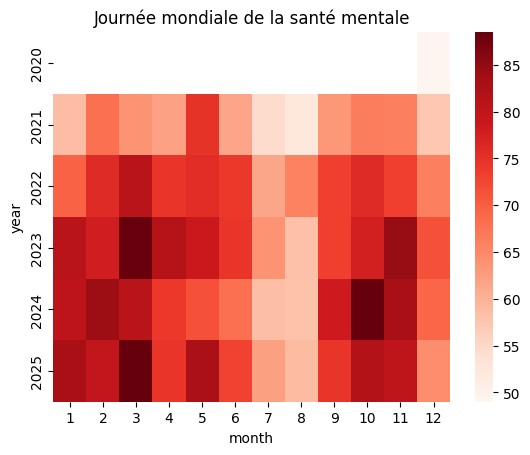

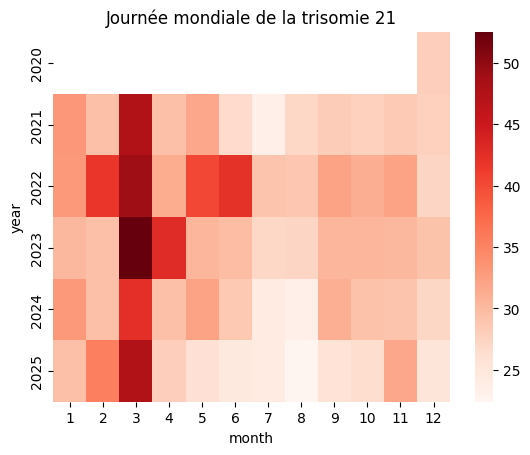

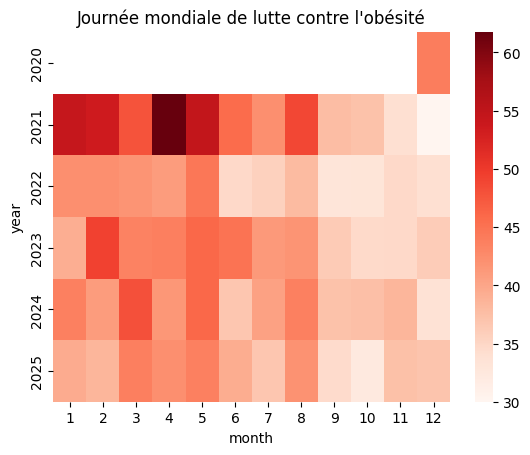

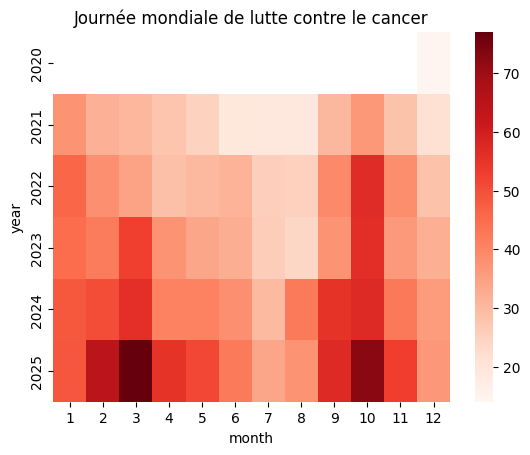

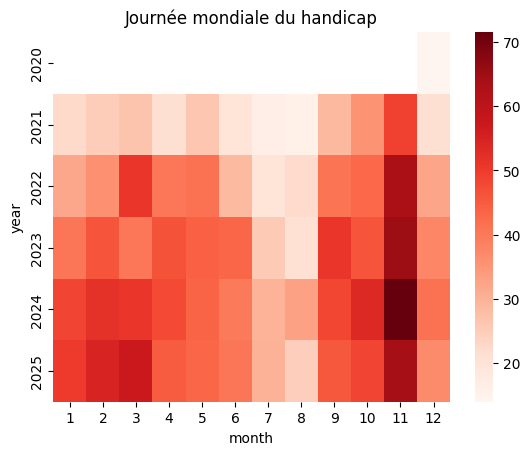

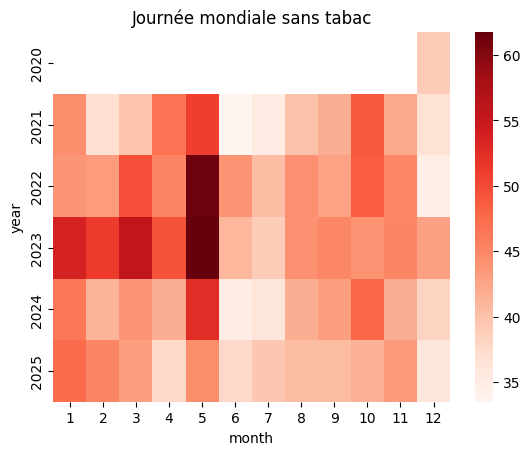

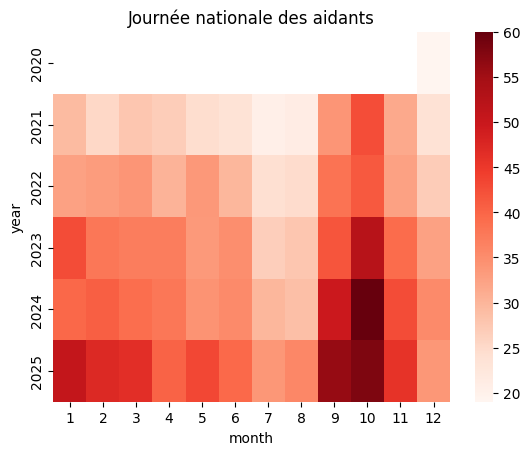

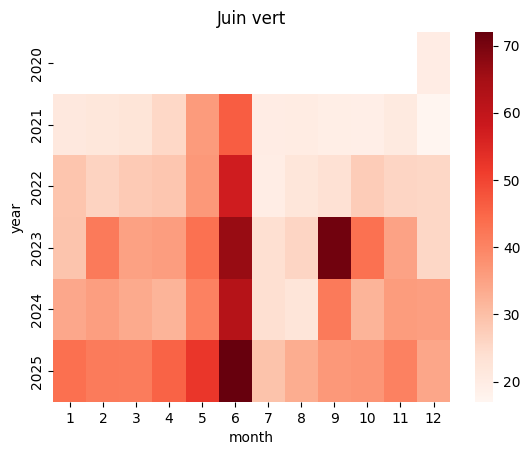

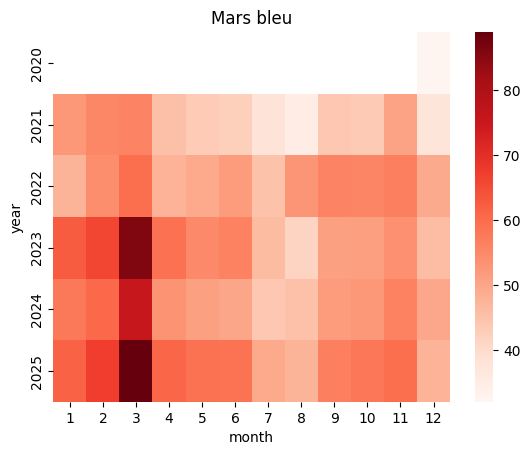

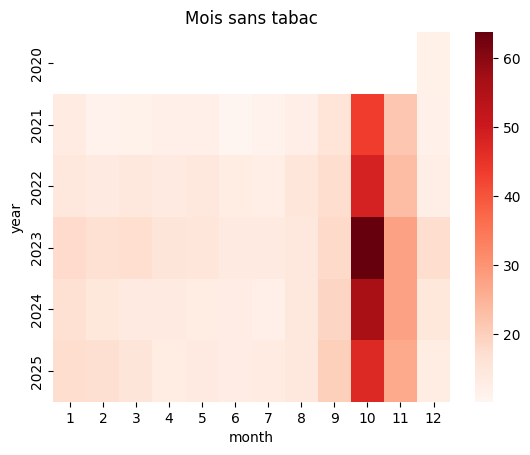

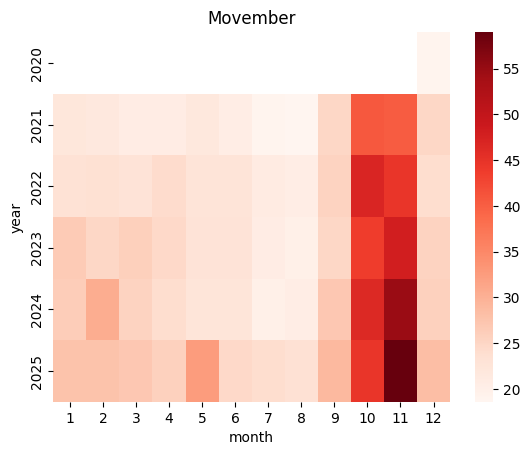

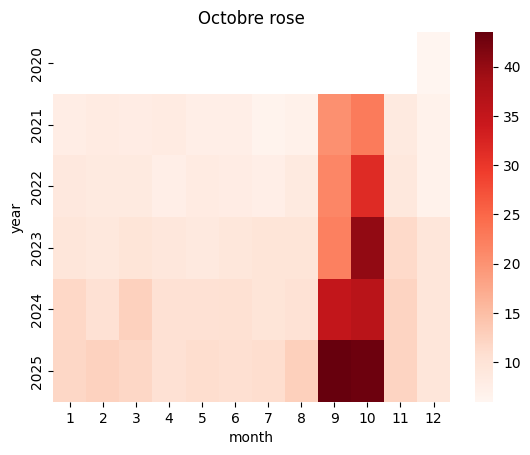

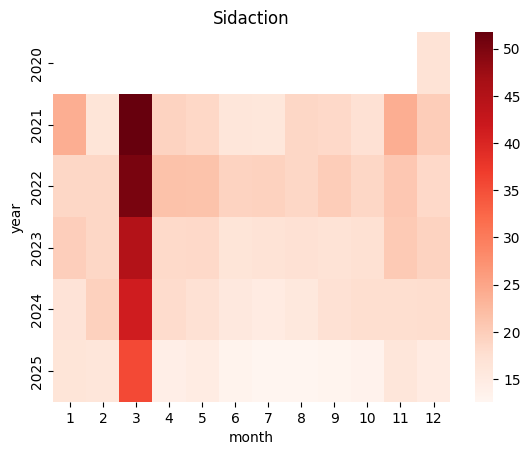

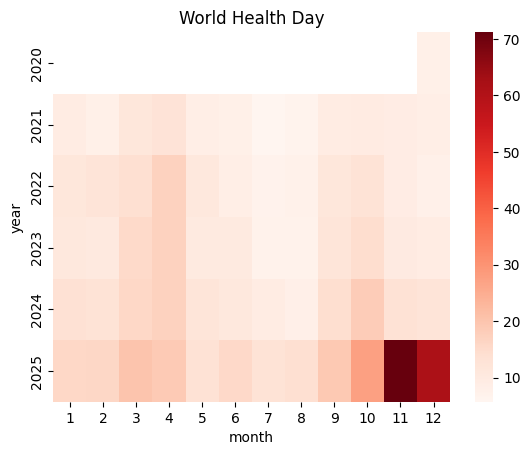

In [19]:
import seaborn as sns

for keyword in df_monthly_wide.columns:
    monthly = df_monthly_wide[keyword].resample("ME").mean()

    temp = monthly.to_frame()
    temp["year"] = temp.index.year
    temp["month"] = temp.index.month

    pivot = temp.pivot(index="year", columns="month", values=keyword)

    sns.heatmap(pivot, cmap="Reds")
    plt.title(keyword)
    plt.show()
    

for keyword in df_weekly_wide.columns:
    monthly = df_weekly_wide[keyword].resample("ME").mean()

    temp = monthly.to_frame()
    temp["year"] = temp.index.year
    temp["month"] = temp.index.month

    pivot = temp.pivot(index="year", columns="month", values=keyword)

    sns.heatmap(pivot, cmap="Reds")
    plt.title(keyword)
    plt.show()